# Fine-tune Empathy Model — CSKH Vietnamese Pair Classification

**Pipeline:** Load CSV → EDA → Feature selection → Stratified split → Tokenize → Train → Evaluate → Save

- **Input:** `data/processed/empathy/empathy_annotation_template.csv` (90 records, balanced 30/30/30)
- **Feature:** `conversation_text` — toàn bộ hội thoại giữ nguyên thứ tự turn
- **Labels:** `low_empathy` / `medium_empathy` / `high_empathy`
- **Backbone:** `xlm-roberta-base` (frozen) — chỉ train classifier head (~590k params)
- **Output:** `models/empathy_xlm_roberta_anhnhc/final_model/`

In [1]:
!pip install transformers datasets accelerate scikit-learn pandas numpy torch -q

In [2]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

BASE_MODEL = "xlm-roberta-base"
DATA_PATH = Path("data/processed/empathy/empathy_annotation_template_1.csv")
OUTPUT_DIR = Path("models/empathy_xlm_roberta_anhnhc/final_model")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL2ID = {"low_empathy": 0, "medium_empathy": 1, "high_empathy": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
MAX_LENGTH = 512

## 1. Load Dataset

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Shape: (90, 8)
Columns: ['conversation_id', 'conversation_text', 'customer_text', 'agent_text', 'empathy_label', 'empathy_score', 'annotator', 'notes']


,conversation_id,conversation_text,customer_text,agent_text,empathy_label,empathy_score,annotator,notes
0,EMP-001,Khach hang: Máy mua 2 ngày màn hình đã sọc rồi...,"Máy mua 2 ngày màn hình đã sọc rồi, bán hàng k...","Dạ em hiểu anh đang rất bực bội, mua máy mới m...",high_empathy,5,claude-sonnet-4-6,"arc đầy đủ, khách tự nhận ra vấn đề"
1,EMP-002,"Khach hang: Laptop mua về cắm sạc không nhận, ...","Laptop mua về cắm sạc không nhận, tức lắm. | T...",Dạ em rất tiếc khi nghe điều này. Anh thử các ...,high_empathy,5,claude-sonnet-4-6,khách chuyển từ tức sang cảm ơn
2,EMP-003,"Khach hang: Tôi đặt hàng thứ Hai, nói thứ Tư g...","Tôi đặt hàng thứ Hai, nói thứ Tư giao, giờ thứ...","Dạ em thật sự xin lỗi anh, trễ 3 ngày so với c...",high_empathy,5,claude-sonnet-4-6,khách chấp nhận sau khi được giải thích và có ...


## 2. EDA

Class distribution:
empathy_label
low_empathy       30
medium_empathy    30
high_empathy      30

Total: 90 records
Balanced: True


/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_29045/1104159357.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(label_order, rotation=10)


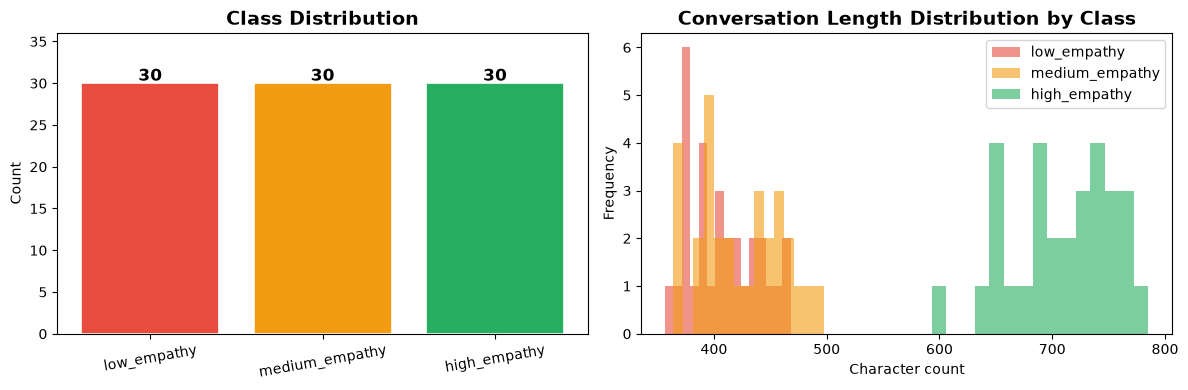


Text length stats per class:
                 mean  min  max
empathy_label                  
low_empathy     407.0  357  468
medium_empathy  423.0  364  498
high_empathy    710.0  593  785


In [4]:
label_order = ["low_empathy", "medium_empathy", "high_empathy"]
label_colors = ["#e74c3c", "#f39c12", "#27ae60"]

counts = df["empathy_label"].value_counts().reindex(label_order)
print("Class distribution:")
print(counts.to_string())
print(f"\nTotal: {len(df)} records")
print(f"Balanced: {counts.min() == counts.max()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution bar chart
axes[0].bar(label_order, counts.values, color=label_colors, edgecolor="white", linewidth=1.2)
for i, (label, val) in enumerate(zip(label_order, counts.values)):
    axes[0].text(i, val + 0.3, str(val), ha="center", fontsize=12, fontweight="bold")
axes[0].set_title("Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, counts.max() * 1.2)
axes[0].set_xticklabels(label_order, rotation=10)

# Text length distribution per class
df["text_len"] = df["conversation_text"].str.len()
for label, color in zip(label_order, label_colors):
    subset = df[df["empathy_label"] == label]["text_len"]
    axes[1].hist(subset, bins=15, alpha=0.6, label=label, color=color)
axes[1].set_title("Conversation Length Distribution by Class", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Character count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nText length stats per class:")
print(df.groupby("empathy_label")["text_len"].agg(["mean", "min", "max"]).round(0).reindex(label_order))

## 3. Feature Selection

In [5]:
# Feature: conversation_text — full conversation in turn order
# Label: empathy_label → label_id (numeric)
X = df["conversation_text"]
y = df["empathy_label"].map(LABEL2ID)

print(f"X shape: {X.shape}  (column: conversation_text)")
print(f"y distribution:\n{y.value_counts().rename({v: k for k, v in LABEL2ID.items()}).to_string()}")
print(f"\nDropped columns: {[c for c in df.columns if c not in ['conversation_text', 'empathy_label']]}")

X shape: (90,)  (column: conversation_text)
y distribution:
empathy_label
high_empathy      30
medium_empathy    30
low_empathy       30

Dropped columns: ['conversation_id', 'customer_text', 'agent_text', 'empathy_score', 'annotator', 'notes', 'text_len']


## 4. Stratified Split (80/20)

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

train_df = pd.DataFrame({"conversation_text": X_train, "label_id": y_train}).reset_index(drop=True)
val_df = pd.DataFrame({"conversation_text": X_val, "label_id": y_val}).reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")
print("\nTrain class distribution:")
print(train_df["label_id"].map(ID2LABEL).value_counts().reindex(label_order))
print("\nVal class distribution:")
print(val_df["label_id"].map(ID2LABEL).value_counts().reindex(label_order))

Train: 72 | Val: 18

Train class distribution:
label_id
low_empathy       24
medium_empathy    24
high_empathy      24
Name: count, dtype: int64

Val class distribution:
label_id
low_empathy       6
medium_empathy    6
high_empathy      6
Name: count, dtype: int64


In [9]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

class EmpathyDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        enc = tokenizer(
            df["conversation_text"].tolist(),
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
        )
        self.input_ids = torch.tensor(enc["input_ids"])
        self.attention_mask = torch.tensor(enc["attention_mask"])
        self.labels = torch.tensor(df["label_id"].tolist())

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx],
        }

train_ds = EmpathyDataset(train_df)
val_ds = EmpathyDataset(val_df)

print(f"train_ds: {len(train_ds)} samples")
print(f"val_ds:   {len(val_ds)} samples")

train_ds: 72 samples
val_ds:   18 samples


## 5. Train

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

# Freeze toàn bộ backbone
for param in model.roberta.parameters():
    param.requires_grad = False

# Unfreeze 2 transformer layer cuối để học được đặc trưng tiếng Việt
for layer in model.roberta.encoder.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

# Balanced dataset (30/30/30) → equal weights
class_weights = torch.tensor([1.0, 1.0, 1.0])

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fn = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(outputs.logits.device)
        )
        loss = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    report = classification_report(
        labels, preds,
        target_names=[ID2LABEL[i] for i in range(3)],
        output_dict=True,
        zero_division=0,
    )
    return {"f1_macro": report["macro avg"]["f1-score"], "accuracy": report["accuracy"]}

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / "checkpoints"),
    num_train_epochs=120,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=20,
    report_to="none",
    fp16=False,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

trainer.train()

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 14,768,643 / 278,045,955 (5.3%)


/Users/anhnguyen/Projects/RND/mseai/CareScore-AI/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,No log,1.098997,0.166667,0.333333
2,No log,1.105448,0.166667,0.333333
3,1.185888,1.101282,0.166667,0.333333
4,1.185888,1.123456,0.166667,0.333333
5,1.147905,1.094344,0.166667,0.333333
6,1.147905,1.103737,0.166667,0.333333
7,1.141349,1.073456,0.166667,0.333333
8,1.141349,0.644084,1.000000,1.000000
9,0.893888,0.639760,0.830769,0.833333
10,0.893888,0.192253,0.944056,0.944444


/Users/anhnguyen/Projects/RND/mseai/CareScore-AI/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/anhnguyen/Projects/RND/mseai/CareScore-AI/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/anhnguyen/Projects/RND/mseai/CareScore-AI/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/anhnguyen/Projects/RND/mseai/CareScore-AI/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned 

TrainOutput(global_step=1080, training_loss=0.09110995177438276, metrics={'train_runtime': 705.7021, 'train_samples_per_second': 12.243, 'train_steps_per_second': 1.53, 'total_flos': 2273299929169920.0, 'train_loss': 0.09110995177438276, 'epoch': 120.0})

## 6. Evaluate

In [ ]:
results = trainer.evaluate()
print(f"Val loss: {results['eval_loss']:.4f} | F1 macro: {results['eval_f1_macro']:.3f} | Accuracy: {results['eval_accuracy']:.3f}")

preds_output = trainer.predict(val_ds)
preds = np.argmax(preds_output.predictions, axis=-1)
true_labels = val_df["label_id"].values
print("\nClassification Report:")
print(classification_report(
    true_labels, preds,
    target_names=[ID2LABEL[i] for i in range(3)],
    zero_division=0,
))

/Users/anhnguyen/Projects/RND/mseai/CareScore-AI/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Training Loss,Validation Loss,Epoch,F1 Macro,Accuracy
0.000029,0.644205,120,0.944056,0.944444


Val loss: 0.6442 | F1 macro: 0.944 | Accuracy: 0.944


/Users/anhnguyen/Projects/RND/mseai/CareScore-AI/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



Classification Report:
                precision    recall  f1-score   support

   low_empathy       1.00      0.83      0.91         6
medium_empathy       0.86      1.00      0.92         6
  high_empathy       1.00      1.00      1.00         6

      accuracy                           0.94        18
     macro avg       0.95      0.94      0.94        18
  weighted avg       0.95      0.94      0.94        18



## 7. Save Model

In [ ]:
trainer.save_model(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))

label_mapping = {"id2label": ID2LABEL, "label2id": LABEL2ID}
(OUTPUT_DIR / "label_mapping.json").write_text(
    json.dumps(label_mapping, ensure_ascii=False, indent=2), encoding="utf-8"
)

print(f"Model saved to: {OUTPUT_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: models/empathy_xlm_roberta_anhnhc/final_model


## 8. Inference Test

In [ ]:
TEST_TRANSCRIPT = """Khach hang: Tôi mua cái điện thoại này mới có 3 ngày mà màn hình đã bị sọc rồi, bán hàng kiểu gì vậy?
Nhan vien: Dạ em hiểu anh đang rất bực bội, mua điện thoại mới mà gặp lỗi như vậy thì ai cũng khó chịu. Anh có thể mô tả thêm sọc màn hình xuất hiện như thế nào không ạ?
Khach hang: Sọc trắng chạy ngang, không va đập gì hết.
Nhan vien: Dạ lỗi phần cứng màn hình, trong 30 ngày được đổi mới hoàn toàn ạ.
Khach hang: Thôi được rồi, lỗi do lô hàng chứ không phải cửa hàng cố tình đâu nhỉ.
Nhan vien: Dạ đúng ạ, cảm ơn anh đã bình tĩnh để em hỗ trợ."""

device = model.device
inputs = tokenizer(TEST_TRANSCRIPT, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)
inputs = {k: v.to(device) for k, v in inputs.items()}
model.eval()
with torch.no_grad():
    logits = model(**inputs).logits
pred_id = int(torch.argmax(logits, dim=-1).item())
score_map = {"low_empathy": 1, "medium_empathy": 3, "high_empathy": 5}
pred_label = ID2LABEL[pred_id]
print(f"Prediction: {pred_label}  →  score: {score_map[pred_label]}")

Prediction: high_empathy  →  score: 5
